# T1.3 — Supply-Demand Features + Unified Model Baseline

This notebook implements the paper's T1.3 workflow:

1. construct market-structure features using only past observations
2. train a pooled model baseline using all tea segments together
3. compare the pooled model against segment-specific results

The central question is whether a unified model can match or outperform segment-specific modeling once supply-demand structure is made explicit.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 160)
pd.set_option('display.max_rows', 120)
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries imported. Random seed set to 42.')

Libraries imported. Random seed set to 42.


## 2. Load Data

The notebook loads the processed tea dataset from the repository, preferring the preprocessed modeling file when available. It also detects the target and segment columns robustly so the workflow still runs if the file structure changes slightly.

In [2]:
def find_repo_root(start_path: Path | None = None) -> Path:
    """Find the repository root by searching upward for the data directory."""
    candidates = []
    if start_path is not None:
        candidates.append(start_path)
    candidates.extend([Path.cwd(), Path.cwd().parent])
    for candidate in candidates:
        for root in [candidate, *candidate.parents]:
            if (root / 'data').exists() and (root / 'src').exists():
                return root
    return Path.cwd()

repo_root = find_repo_root()
processed_dir = repo_root / 'data' / 'Processed'
reports_dir = repo_root / 'reports' / 'figures'
reports_dir.mkdir(parents=True, exist_ok=True)

data_candidates = [
    processed_dir / 'tea_preprocessed.csv',
    processed_dir / 'reduced_master_tea_prices.csv',
    processed_dir / 'master_tea_prices.csv',
]
input_path = next((path for path in data_candidates if path.exists()), None)
if input_path is None:
    raise FileNotFoundError('No processed dataset found in data/Processed.')

df = pd.read_csv(input_path)
print(f'Loaded dataset: {input_path}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')

target_candidates = ['price_mid_lkr_log', 'price_mid_lkr']
target_col = next((c for c in target_candidates if c in df.columns), None)
if target_col is None:
    raise ValueError('Could not locate a target column.')

segment_candidates = ['category_type', 'table_source', 'elevation', 'category']
segment_col = next((c for c in segment_candidates if c in df.columns), None)
if segment_col is None:
    raise ValueError('Could not locate a segment/category column.')

print('Target column:', target_col)
print('Segment column:', segment_col)
display(df.head(5))
print('Columns:')
print(list(df.columns))

Loaded dataset: d:\Projects\data-analysis-for-tea-industry\data\Processed\tea_preprocessed.csv
Shape: 11,523 rows x 185 columns
Target column: price_mid_lkr_log
Segment column: category_type


,sale_id,sale_number,sale_year,sale_month,sale_date_raw,table_source,elevation,category_type,grade,tier,category,price_lo_lkr,price_hi_lkr,price_mid_lkr,price_range_lkr,total_lots,total_kgs,reprint_lots,reprint_quantity,sentiment_overall,sentiment_ex_estate,sentiment_low_grown,western_nuwara_eliya_weather_score,uva_udapussellawa_weather_score,low_grown_weather_score,avg_weather_severity,crop_nuwara_eliya_trend,crop_western_trend,crop_uva_trend,crop_low_grown_trend,sl_production_mkgs,fx_usd_2026,fx_usd_2025,fx_gbp_2026,fx_gbp_2025,fx_eur_2026,fx_eur_2025,fx_jpy_2026,fx_jpy_2025,private_sales_weekly_2026,private_sales_weekly_2025,private_sales_todate_2026,private_sales_todate_2025,public_auction_weekly_2026,public_auction_weekly_2025,public_auction_todate_2026,public_auction_todate_2025,forward_contracts_weekly_2026,forward_contracts_weekly_2025,forward_contracts_todate_2026,forward_contracts_todate_2025,total_sold_weekly_2026,total_sold_weekly_2025,total_sold_todate_2026,total_sold_todate_2025,volume_yoy_change_pct,dust__demand_score,ex_estate__demand_score,leafy__demand_score,off_grade__demand_score,premium_flowery__demand_score,semi_leafy__demand_score,dust__qty_mkgs,ex_estate__qty_mkgs,high_medium__qty_mkgs,leafy__qty_mkgs,off_grade__qty_mkgs,premium_flowery__qty_mkgs,semi_leafy__qty_mkgs,tippy__qty_mkgs,total__qty_mkgs,low_grown__precipitation_sum_total,nuwara_eliya__precipitation_sum_total,uva_udapussellawa__precipitation_sum_total,western_high__precipitation_sum_total,low_grown__precipitation_sum_total_lag1,nuwara_eliya__precipitation_sum_total_lag1,uva_udapussellawa__precipitation_sum_total_lag1,western_high__precipitation_sum_total_lag1,low_grown__precipitation_sum_total_lag2,nuwara_eliya__precipitation_sum_total_lag2,uva_udapussellawa__precipitation_sum_total_lag2,western_high__precipitation_sum_total_lag2,low_grown__precipitation_sum_total_lag3,nuwara_eliya__precipitation_sum_total_lag3,uva_udapussellawa__precipitation_sum_total_lag3,western_high__precipitation_sum_total_lag3,low_grown__rain_sum_total_lag1,nuwara_eliya__rain_sum_total_lag1,uva_udapussellawa__rain_sum_total_lag1,western_high__rain_sum_total_lag1,low_grown__rain_sum_total_lag2,nuwara_eliya__rain_sum_total_lag2,uva_udapussellawa__rain_sum_total_lag2,western_high__rain_sum_total_lag2,low_grown__rain_sum_total_lag3,nuwara_eliya__rain_sum_total_lag3,uva_udapussellawa__rain_sum_total_lag3,western_high__rain_sum_total_lag3,uva_udapussellawa__relative_humidity_2m_max_max,western_high__relative_humidity_2m_max_max,low_grown__relative_humidity_2m_max_mean,nuwara_eliya__relative_humidity_2m_max_mean,uva_udapussellawa__relative_humidity_2m_max_mean,western_high__relative_humidity_2m_max_mean,low_grown__relative_humidity_2m_min_mean,nuwara_eliya__relative_humidity_2m_min_mean,uva_udapussellawa__relative_humidity_2m_min_mean,western_high__relative_humidity_2m_min_mean,low_grown__sunshine_duration_total,nuwara_eliya__sunshine_duration_total,uva_udapussellawa__sunshine_duration_total,western_high__sunshine_duration_total,low_grown__sunshine_duration_total_lag1,nuwara_eliya__sunshine_duration_total_lag1,uva_udapussellawa__sunshine_duration_total_lag1,western_high__sunshine_duration_total_lag1,low_grown__sunshine_duration_total_lag2,nuwara_eliya__sunshine_duration_total_lag2,uva_udapussellawa__sunshine_duration_total_lag2,western_high__sunshine_duration_total_lag2,low_grown__sunshine_duration_total_lag3,nuwara_eliya__sunshine_duration_total_lag3,uva_udapussellawa__sunshine_duration_total_lag3,western_high__sunshine_duration_total_lag3,low_grown__temperature_2m_mean_mean,nuwara_eliya__temperature_2m_mean_mean,uva_udapussellawa__temperature_2m_mean_mean,western_high__temperature_2m_mean_mean,low_grown__temperature_2m_mean_mean_lag1,nuwara_eliya__temperature_2m_mean_mean_lag1,uva_udapussellawa__temperature_2m_mean_mean_lag1,western_high__temperature_2m_mean_mean_lag1,low_grown__temperature_2m_mean_mean_lag2,nuwara_eliya__temperature_2m_mean_mean_lag2,uva_udapussellawa__tem

Columns:
['sale_id', 'sale_number', 'sale_year', 'sale_month', 'sale_date_raw', 'table_source', 'elevation', 'category_type', 'grade', 'tier', 'category', 'price_lo_lkr', 'price_hi_lkr', 'price_mid_lkr', 'price_range_lkr', 'total_lots', 'total_kgs', 'reprint_lots', 'reprint_quantity', 'sentiment_overall', 'sentiment_ex_estate', 'sentiment_low_grown', 'western_nuwara_eliya_weather_score', 'uva_udapussellawa_weather_score', 'low_grown_weather_score', 'avg_weather_severity', 'crop_nuwara_eliya_trend', 'crop_western_trend', 'crop_uva_trend', 'crop_low_grown_trend', 'sl_production_mkgs', 'fx_usd_2026', 'fx_usd_2025', 'fx_gbp_2026', 'fx_gbp_2025', 'fx_eur_2026', 'fx_eur_2025', 'fx_jpy_2026', 'fx_jpy_2025', 'private_sales_weekly_2026', 'private_sales_weekly_2025', 'private_sales_todate_2026', 'private_sales_todate_2025', 'public_auction_weekly_2026', 'public_auction_weekly_2025', 'public_auction_todate_2026', 'public_auction_todate_2025', 'forward_contracts_weekly_2026', 'forward_contracts_we

## 3. Initial Inspection

This section checks missingness, data types, and the columns most relevant to supply, demand, and auction timing. The goal is to verify the dataset structure before feature engineering.

In [3]:
inspection_groups = {
    'offered_volume': [c for c in df.columns if 'qty' in c.lower() or 'offer' in c.lower() or 'offering' in c.lower()],
    'demand_score': [c for c in df.columns if 'demand' in c.lower()],
    'sale_timing': [c for c in ['sale_year', 'sale_month', 'sale_number', 'sale_date_raw', 'sale_id'] if c in df.columns],
    'segment_ids': [c for c in ['category_type', 'table_source', 'elevation', 'category', 'grade', 'tier'] if c in df.columns],
}

missing = df.isna().mean().sort_values(ascending=False)
dtype_frame = df.dtypes.astype(str).rename('dtype').to_frame()
inspection_report = pd.concat([dtype_frame, df.isna().sum().rename('missing_count'), (df.isna().mean() * 100).rename('missing_pct')], axis=1)

print('Missing values by column (top 25):')
display(missing.head(25).to_frame('missing_pct'))

print('Dtypes:')
display(dtype_frame.T)

for name, cols in inspection_groups.items():
    print(f'\n{name}:')
    print(cols if cols else 'No matching columns found.')

print('Sample rows for inspection:')
sample_cols = sorted(set(sum(inspection_groups.values(), []) + [target_col]))
display(df[sample_cols].head(10))

Missing values by column (top 25):


,missing_pct
tier,0.559837
ex_estate__qty_mkgs,0.410657
ex_estate__demand_score,0.410657
semi_leafy__qty_mkgs,0.406144
semi_leafy__demand_score,0.406144
grade,0.386618
high_medium__qty_mkgs,0.176864
crop_uva_trend,0.136162
crop_low_grown_trend,0.136162
crop_nuwara_eliya_trend,0.136162


Dtypes:


,sale_id,sale_number,sale_year,sale_month,sale_date_raw,table_source,elevation,category_type,grade,tier,category,price_lo_lkr,price_hi_lkr,price_mid_lkr,price_range_lkr,total_lots,total_kgs,reprint_lots,reprint_quantity,sentiment_overall,sentiment_ex_estate,sentiment_low_grown,western_nuwara_eliya_weather_score,uva_udapussellawa_weather_score,low_grown_weather_score,avg_weather_severity,crop_nuwara_eliya_trend,crop_western_trend,crop_uva_trend,crop_low_grown_trend,sl_production_mkgs,fx_usd_2026,fx_usd_2025,fx_gbp_2026,fx_gbp_2025,fx_eur_2026,fx_eur_2025,fx_jpy_2026,fx_jpy_2025,private_sales_weekly_2026,private_sales_weekly_2025,private_sales_todate_2026,private_sales_todate_2025,public_auction_weekly_2026,public_auction_weekly_2025,public_auction_todate_2026,public_auction_todate_2025,forward_contracts_weekly_2026,forward_contracts_weekly_2025,forward_contracts_todate_2026,forward_contracts_todate_2025,total_sold_weekly_2026,total_sold_weekly_2025,total_sold_todate_2026,total_sold_todate_2025,volume_yoy_change_pct,dust__demand_score,ex_estate__demand_score,leafy__demand_score,off_grade__demand_score,premium_flowery__demand_score,semi_leafy__demand_score,dust__qty_mkgs,ex_estate__qty_mkgs,high_medium__qty_mkgs,leafy__qty_mkgs,off_grade__qty_mkgs,premium_flowery__qty_mkgs,semi_leafy__qty_mkgs,tippy__qty_mkgs,total__qty_mkgs,low_grown__precipitation_sum_total,nuwara_eliya__precipitation_sum_total,uva_udapussellawa__precipitation_sum_total,western_high__precipitation_sum_total,low_grown__precipitation_sum_total_lag1,nuwara_eliya__precipitation_sum_total_lag1,uva_udapussellawa__precipitation_sum_total_lag1,western_high__precipitation_sum_total_lag1,low_grown__precipitation_sum_total_lag2,nuwara_eliya__precipitation_sum_total_lag2,uva_udapussellawa__precipitation_sum_total_lag2,western_high__precipitation_sum_total_lag2,low_grown__precipitation_sum_total_lag3,nuwara_eliya__precipitation_sum_total_lag3,uva_udapussellawa__precipitation_sum_total_lag3,western_high__precipitation_sum_total_lag3,low_grown__rain_sum_total_lag1,nuwara_eliya__rain_sum_total_lag1,uva_udapussellawa__rain_sum_total_lag1,western_high__rain_sum_total_lag1,low_grown__rain_sum_total_lag2,nuwara_eliya__rain_sum_total_lag2,uva_udapussellawa__rain_sum_total_lag2,western_high__rain_sum_total_lag2,low_grown__rain_sum_total_lag3,nuwara_eliya__rain_sum_total_lag3,uva_udapussellawa__rain_sum_total_lag3,western_high__rain_sum_total_lag3,uva_udapussellawa__relative_humidity_2m_max_max,western_high__relative_humidity_2m_max_max,low_grown__relative_humidity_2m_max_mean,nuwara_eliya__relative_humidity_2m_max_mean,uva_udapussellawa__relative_humidity_2m_max_mean,western_high__relative_humidity_2m_max_mean,low_grown__relative_humidity_2m_min_mean,nuwara_eliya__relative_humidity_2m_min_mean,uva_udapussellawa__relative_humidity_2m_min_mean,western_high__relative_humidity_2m_min_mean,low_grown__sunshine_duration_total,nuwara_eliya__sunshine_duration_total,uva_udapussellawa__sunshine_duration_total,western_high__sunshine_duration_total,low_grown__sunshine_duration_total_lag1,nuwara_eliya__sunshine_duration_total_lag1,uva_udapussellawa__sunshine_duration_total_lag1,western_high__sunshine_duration_total_lag1,low_grown__sunshine_duration_total_lag2,nuwara_eliya__sunshine_duration_total_lag2,uva_udapussellawa__sunshine_duration_total_lag2,western_high__sunshine_duration_total_lag2,low_grown__sunshine_duration_total_lag3,nuwara_eliya__sunshine_duration_total_lag3,uva_udapussellawa__sunshine_duration_total_lag3,western_high__sunshine_duration_total_lag3,low_grown__temperature_2m_mean_mean,nuwara_eliya__temperature_2m_mean_mean,uva_udapussellawa__temperature_2m_mean_mean,western_high__temperature_2m_mean_mean,low_grown__temperature_2m_mean_mean_lag1,nuwara_eliya__temperature_2m_mean_mean_lag1,uva_udapussellawa__temperature_2m_mean_mean_lag1,western_high__temperature_2m_mean_mean_lag1,low_grown__temperature_2m_mean_mean_lag2,nuwara_eliya__temperature_2m_mean_mean_lag2,uva_udapussellawa__tem


offered_volume:
['dust__qty_mkgs', 'ex_estate__qty_mkgs', 'high_medium__qty_mkgs', 'leafy__qty_mkgs', 'off_grade__qty_mkgs', 'premium_flowery__qty_mkgs', 'semi_leafy__qty_mkgs', 'tippy__qty_mkgs', 'total__qty_mkgs']

demand_score:
['dust__demand_score', 'ex_estate__demand_score', 'leafy__demand_score', 'off_grade__demand_score', 'premium_flowery__demand_score', 'semi_leafy__demand_score', 'demand_intensity_ratio']

sale_timing:
['sale_year', 'sale_month', 'sale_number', 'sale_date_raw', 'sale_id']

segment_ids:
['category_type', 'table_source', 'elevation', 'category', 'grade', 'tier']
Sample rows for inspection:


,category,category_type,demand_intensity_ratio,dust__demand_score,dust__qty_mkgs,elevation,ex_estate__demand_score,ex_estate__qty_mkgs,grade,high_medium__qty_mkgs,leafy__demand_score,leafy__qty_mkgs,off_grade__demand_score,off_grade__qty_mkgs,premium_flowery__demand_score,premium_flowery__qty_mkgs,price_mid_lkr_log,sale_date_raw,sale_id,sale_month,sale_number,sale_year,semi_leafy__demand_score,semi_leafy__qty_mkgs,table_source,tier,tippy__qty_mkgs,total__qty_mkgs
0,below_best_western,high_grown,NaN,NaN,NaN,high_grown,NaN,NaN,bop,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.030857,04TH/05TH January 2024,SALE_01_2024,January,1,2024.0,NaN,NaN,04_high_grown,NaN,NaN,NaN
1,below_best_western,high_grown,NaN,NaN,NaN,high_grown,NaN,NaN,bopf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.048386,04TH/05TH January 2024,SALE_01_2024,January,1,2024.0,NaN,NaN,04_high_grown,NaN,NaN,NaN
2,below_best_western,high_grown,NaN,NaN,NaN,high_grown,NaN,NaN,pekoe_fbop,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.065613,04TH/05TH January 2024,SALE_01_2024,January,1,2024.0,NaN,NaN,04_high_grown,NaN,NaN,NaN
3,below_best_western,high_grown,NaN,NaN,NaN,high_grown,NaN,NaN,op,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.003974,04TH/05TH January 2024,SALE_01_2024,January,1,2024.0,NaN,NaN,04_high_grown,NaN,NaN,NaN
4,best_uva,high_grown,NaN,NaN,NaN,high_grown,NaN,NaN,bop,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.013016,04TH/05TH January 2024,SALE_01_2024,January,1,2024.0,NaN,NaN,04_high_grown,NaN,NaN,NaN
5,best_uva,high_grown,NaN,NaN,NaN,high_grown,NaN,NaN,bopf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.918695,04TH/05TH January 2024,SALE_01_2024,January,1,2024.0,NaN,NaN,04_high_grown,NaN,NaN,NaN
6,best_uva,high_grown,NaN,NaN,NaN,high_grown,NaN,NaN,pekoe_fbop,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.336937,04TH/05TH January 2024,SALE_01_2024,January,1,2024.0,NaN,NaN,04_high_grown,NaN,NaN,NaN
7,best_uva,high_grown,NaN,NaN,NaN,high_grown,NaN,NaN,op,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.201171,04TH/05TH January 2024,SALE_01_2024,January,1,2024.0,NaN,NaN,04_high_grown,NaN,NaN,NaN
8,best_western,high_grown,NaN,NaN,NaN,high_grown,NaN,NaN,bop,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.163172,04TH/05TH January 2024,SALE_01_2024,January,1,2024.0,NaN,NaN,04_high_grown,NaN,NaN,NaN
9,best_western,high_grown,NaN,NaN,NaN,high_grown,NaN,NaN,bopf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.163172,04TH/05TH January 2024,SALE_01_2024,January,1,2024.0,NaN,NaN,04_high_grown,NaN,NaN,NaN


## 4. Feature Engineering

The three market-structure variables are built from current sale information and past-only historical averages. The notebook uses an expanding mean shifted by one observation, so the current sale never contributes to its own baseline.

Assumption used here:

- `supply_pressure_index` uses total offered volume, detected from the strongest available quantity column, usually `total__qty_mkgs`.
- `demand_intensity_ratio` uses a sale-level demand proxy built from all available demand-score columns. If a total demand column exists, it is used; otherwise the row-wise mean of the available demand columns is used.
- Historical baselines are computed within `category_type` when available, otherwise within `table_source`, otherwise globally.

This keeps the feature construction stable while remaining robust to small schema changes.

In [4]:
def first_existing(columns: list[str], candidates: list[str]) -> str | None:
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None

def parse_sale_order(frame: pd.DataFrame) -> pd.DataFrame:
    order = frame.copy()
    if 'sale_date_raw' in order.columns:
        order['_sale_date_parsed'] = pd.to_datetime(order['sale_date_raw'], errors='coerce', dayfirst=True)
    else:
        order['_sale_date_parsed'] = pd.NaT
    if 'sale_number' in order.columns:
        order['_sale_number_numeric'] = pd.to_numeric(order['sale_number'], errors='coerce')
    else:
        order['_sale_number_numeric'] = np.nan
    sort_cols = ['_sale_date_parsed', '_sale_number_numeric', 'sale_id'] if 'sale_id' in order.columns else ['_sale_date_parsed', '_sale_number_numeric']
    order = order.sort_values(sort_cols, kind='mergesort').reset_index(drop=True)
    order['_sale_order'] = np.arange(len(order))
    return order

def select_history_group_columns(frame: pd.DataFrame) -> list[str]:
    if 'category_type' in frame.columns:
        return ['category_type']
    if 'table_source' in frame.columns:
        return ['table_source']
    return []

def build_market_structure_features(frame: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, str]]:
    work = frame.copy()
    mapping: dict[str, str] = {}

    supply_col = first_existing(work.columns.tolist(), ['total__qty_mkgs', 'qty_mkgs', 'total_kgs', 'total_lots'])
    demand_cols = [c for c in work.columns if c.endswith('__demand_score')]
    total_demand_col = first_existing(work.columns.tolist(), ['total__demand_score', 'demand_score', 'market_demand_score'])
    history_group_cols = select_history_group_columns(work)

    if supply_col is None:
        raise ValueError('Could not identify an offered-volume column.')
    if not demand_cols and total_demand_col is None:
        raise ValueError('Could not identify any demand-score columns.')

    mapping['supply_column'] = supply_col
    mapping['demand_columns'] = ', '.join(demand_cols) if demand_cols else total_demand_col
    mapping['history_group_columns'] = ', '.join(history_group_cols) if history_group_cols else 'global'

    order_frame = parse_sale_order(work)
    keep_cols = ['sale_id'] if 'sale_id' in order_frame.columns else []
    keep_cols += history_group_cols
    keep_cols += [c for c in ['_sale_order', supply_col] if c in order_frame.columns]
    if total_demand_col is not None:
        keep_cols.append(total_demand_col)
    if demand_cols:
        keep_cols.extend(demand_cols)
    if 'sale_number' in order_frame.columns:
        keep_cols.append('sale_number')
    if 'sale_date_raw' in order_frame.columns:
        keep_cols.append('sale_date_raw')

    sale_level = order_frame[keep_cols].drop_duplicates(subset=['sale_id'] + history_group_cols if history_group_cols else ['sale_id']).copy()
    sale_level = sale_level.sort_values(['_sale_order'] + history_group_cols if history_group_cols else ['_sale_order'], kind='mergesort').reset_index(drop=True)

    if total_demand_col is not None:
        sale_level['_current_demand_proxy'] = pd.to_numeric(sale_level[total_demand_col], errors='coerce')
    else:
        sale_level['_current_demand_proxy'] = sale_level[demand_cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)

    sale_level['_current_supply_proxy'] = pd.to_numeric(sale_level[supply_col], errors='coerce')

    if history_group_cols:
        sale_level['_historical_supply_avg'] = (
            sale_level.groupby(history_group_cols, sort=False)['_current_supply_proxy']
            .transform(lambda s: s.expanding(min_periods=1).mean().shift(1))
        )
        sale_level['_historical_demand_avg'] = (
            sale_level.groupby(history_group_cols, sort=False)['_current_demand_proxy']
            .transform(lambda s: s.expanding(min_periods=1).mean().shift(1))
        )
    else:
        sale_level['_historical_supply_avg'] = sale_level['_current_supply_proxy'].expanding(min_periods=1).mean().shift(1)
        sale_level['_historical_demand_avg'] = sale_level['_current_demand_proxy'].expanding(min_periods=1).mean().shift(1)

    sale_level['supply_pressure_index'] = np.divide(
        sale_level['_current_supply_proxy'],
        sale_level['_historical_supply_avg'].replace({0: np.nan}),
    )
    sale_level['demand_intensity_ratio'] = np.divide(
        sale_level['_current_demand_proxy'],
        sale_level['_historical_demand_avg'].replace({0: np.nan}),
    )
    sale_level['market_tightness_indicator'] = np.divide(
        sale_level['demand_intensity_ratio'],
        sale_level['supply_pressure_index'].replace({0: np.nan}),
    )

    feature_cols = ['sale_id'] + history_group_cols + [
        '_current_supply_proxy', '_current_demand_proxy', '_historical_supply_avg', '_historical_demand_avg',
        'supply_pressure_index', 'demand_intensity_ratio', 'market_tightness_indicator',
    ]
    feature_frame = sale_level[feature_cols].copy()
    enriched = work.merge(feature_frame, on=(['sale_id'] + history_group_cols if history_group_cols else ['sale_id']), how='left')

    return enriched, mapping

df_features, feature_mapping = build_market_structure_features(df)
print('Detected feature mapping:')
for key, value in feature_mapping.items():
    print(f'  {key}: {value}')

new_feature_cols = ['supply_pressure_index', 'demand_intensity_ratio', 'market_tightness_indicator']
display(df_features[new_feature_cols].describe().T)

enriched_output = processed_dir / 'tea_preprocessed_t13_supply_demand.csv'
df_features.to_csv(enriched_output, index=False)
print(f'Saved enriched dataset to: {enriched_output}')

Detected feature mapping:
  supply_column: total__qty_mkgs
  demand_columns: dust__demand_score, ex_estate__demand_score, leafy__demand_score, off_grade__demand_score, premium_flowery__demand_score, semi_leafy__demand_score
  history_group_columns: category_type


KeyError: "None of [Index(['supply_pressure_index', 'demand_intensity_ratio', 'market_tightness_indicator'], dtype='str')] are in the [columns]"

## 5. Data Preparation for Modeling

The pooled baseline uses a chronological split, not a random split, because the observations are ordered auction sales. The notebook uses the existing encoded numeric columns from preprocessing, plus the new market-structure features.

Important exclusion rules:

- remove the modeling target itself
- remove direct leakage columns such as `price_lo_lkr`, `price_hi_lkr`, and `price_range_lkr`
- remove derived target proxies such as `price_mid_usd`
- keep the split reproducible by sorting unique sales chronologically

In [ ]:
def get_sort_frame(frame: pd.DataFrame) -> pd.DataFrame:
    sort_frame = frame[['sale_id']].drop_duplicates().copy()
    if 'sale_date_raw' in frame.columns:
        date_map = frame[['sale_id', 'sale_date_raw']].drop_duplicates('sale_id')
        date_map['_sale_date_parsed'] = pd.to_datetime(date_map['sale_date_raw'], errors='coerce', dayfirst=True)
        sort_frame = sort_frame.merge(date_map[['sale_id', '_sale_date_parsed']], on='sale_id', how='left')
    else:
        sort_frame['_sale_date_parsed'] = pd.NaT
    if 'sale_number' in frame.columns:
        num_map = frame[['sale_id', 'sale_number']].drop_duplicates('sale_id')
        num_map['_sale_number_numeric'] = pd.to_numeric(num_map['sale_number'], errors='coerce')
        sort_frame = sort_frame.merge(num_map[['sale_id', '_sale_number_numeric']], on='sale_id', how='left')
    else:
        sort_frame['_sale_number_numeric'] = np.nan
    sort_frame = sort_frame.sort_values(['_sale_date_parsed', '_sale_number_numeric', 'sale_id'], kind='mergesort').reset_index(drop=True)
    sort_frame['_sale_rank'] = np.arange(1, len(sort_frame) + 1)
    return sort_frame

sort_frame = get_sort_frame(df_features)
unique_sales = sort_frame['sale_id'].tolist()
test_sale_count = min(5, max(1, len(unique_sales) // 5))
test_sales = unique_sales[-test_sale_count:]
train_sales = unique_sales[:-test_sale_count]

target_for_model = 'price_mid_lkr_log' if 'price_mid_lkr_log' in df_features.columns else 'price_mid_lkr'
if target_for_model == 'price_mid_lkr' and 'price_mid_lkr' in df_features.columns:
    df_features = df_features.copy()
    df_features['price_mid_lkr_log'] = np.log1p(df_features['price_mid_lkr'])
    target_for_model = 'price_mid_lkr_log'

exclude_cols = {
    'sale_id', 'sale_date_raw', 'sale_month', 'grade', 'tier', 'category_type', 'table_source', 'elevation', 'category',
    'price_lo_lkr', 'price_hi_lkr', 'price_range_lkr', 'price_mid_lkr', 'price_mid_lkr_log', 'has_price_target',
    'price_mid_usd',
}
exclude_cols.update({'_sale_date_parsed', '_sale_number_numeric', '_sale_order', '_current_supply_proxy', '_current_demand_proxy', '_historical_supply_avg', '_historical_demand_avg'})

feature_cols = [c for c in df_features.columns if c not in exclude_cols and c != target_for_model]
numeric_feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_features[c])]

X = df_features[numeric_feature_cols].copy()
y_log = df_features[target_for_model].copy()

# Keep only rows that have valid target and a known sale_id for supervised training/evaluation.
supervised_mask = y_log.notna() & df_features['sale_id'].notna()
X = X.loc[supervised_mask].copy()
y_log = y_log.loc[supervised_mask].copy()
df_supervised = df_features.loc[supervised_mask].copy()

sale_mask_train = df_supervised['sale_id'].isin(train_sales)
sale_mask_test = df_supervised['sale_id'].isin(test_sales)
X_train, X_test = X.loc[sale_mask_train], X.loc[sale_mask_test]
y_train_log, y_test_log = y_log.loc[sale_mask_train], y_log.loc[sale_mask_test]
y_train_lkr = np.expm1(y_train_log)
y_test_lkr = np.expm1(y_test_log)

if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError('Train/test split produced an empty set. Check sale ordering and target availability.')

print(f'Train sales: {len(train_sales)} | Test sales: {len(test_sales)}')
print(f'Supervised rows after target filtering: {len(df_supervised):,}')
print(f'Train rows: {len(X_train):,} | Test rows: {len(X_test):,}')
print(f'Numeric features used for pooled model: {len(numeric_feature_cols)}')
print('First 25 feature columns:')
print(numeric_feature_cols[:25])

X_train_imputed = SimpleImputer(strategy='median').fit_transform(X_train)
print('Missing values in training features after imputation are handled inside the modeling pipeline.')

Train sales: 21 | Test sales: 5
Supervised rows after target filtering: 2,886
Train rows: 2,380 | Test rows: 506
Numeric features used for pooled model: 169
First 25 feature columns:
['sale_number', 'sale_year', 'total_lots', 'total_kgs', 'reprint_lots', 'reprint_quantity', 'sentiment_overall', 'sentiment_ex_estate', 'sentiment_low_grown', 'western_nuwara_eliya_weather_score', 'uva_udapussellawa_weather_score', 'low_grown_weather_score', 'avg_weather_severity', 'crop_nuwara_eliya_trend', 'crop_western_trend', 'crop_uva_trend', 'crop_low_grown_trend', 'sl_production_mkgs', 'fx_usd_2026', 'fx_usd_2025', 'fx_gbp_2026', 'fx_gbp_2025', 'fx_eur_2026', 'fx_eur_2025', 'fx_jpy_2026']
Missing values in training features after imputation are handled inside the modeling pipeline.


## 6. Unified (Pooled) Baseline Model

Two pooled models are trained as baselines: a linear reference model and a random forest model. The main comparison uses the model with the lowest test RMSE on the pooled holdout sales.

The primary output is reported in LKR space after back-transforming the `log1p` target.

In [ ]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-9, np.nan, y_true)
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}

def fit_and_score(name: str, model: Pipeline) -> dict[str, object]:
    model.fit(X_train, y_train_log)
    pred_log = model.predict(X_test)
    pred_lkr = np.expm1(pred_log)
    metrics = regression_metrics(y_test_lkr.to_numpy(), pred_lkr)
    return {'model_name': name, 'model': model, 'pred_log': pred_log, 'pred_lkr': pred_lkr, 'metrics': metrics}

linear_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression()),
])
rf_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    )),
])

model_runs = [
    fit_and_score('LinearRegression', linear_model),
    fit_and_score('RandomForestRegressor', rf_model),
]

pooled_results = pd.DataFrame([
    {'model': run['model_name'], **run['metrics']} for run in model_runs
]).sort_values('rmse').reset_index(drop=True)
display(pooled_results)

best_run = min(model_runs, key=lambda run: run['metrics']['rmse'])
best_model_name = best_run['model_name']
best_model = best_run['model']
y_pred_test_lkr = best_run['pred_lkr']
pooled_metrics = best_run['metrics']

print(f'Chosen pooled baseline: {best_model_name}')
print(pooled_metrics)

pooled_predictions = df_supervised.loc[sale_mask_test, ['sale_id'] + [segment_col]].copy()
pooled_predictions['actual_lkr'] = y_test_lkr.to_numpy()
pooled_predictions['predicted_lkr'] = y_pred_test_lkr
pooled_predictions['abs_error_lkr'] = np.abs(pooled_predictions['actual_lkr'] - pooled_predictions['predicted_lkr'])
pooled_predictions['squared_error_lkr'] = (pooled_predictions['actual_lkr'] - pooled_predictions['predicted_lkr']) ** 2
display(pooled_predictions.head(10))

pooled_metrics_path = processed_dir / 't1_3_pooled_baseline_metrics.csv'
pooled_results.to_csv(pooled_metrics_path, index=False)
print(f'Saved pooled model metrics to: {pooled_metrics_path}')

,model,rmse,mae,r2,mape
0,RandomForestRegressor,469.283103,253.855304,0.489927,18.231812
1,LinearRegression,475.305132,255.737768,0.476752,18.350469


Chosen pooled baseline: RandomForestRegressor
{'rmse': 469.28310341857286, 'mae': 253.85530363268091, 'r2': 0.489926892498484, 'mape': np.float64(18.23181164773876)}


,sale_id,category_type,actual_lkr,predicted_lkr,abs_error_lkr,squared_error_lkr
363,SALE_38_2025,low_grown,1200.0,1362.337417,162.337417,26353.437031
364,SALE_38_2025,low_grown,1425.0,1631.965348,206.965348,42834.655215
365,SALE_38_2025,low_grown,950.0,969.986537,19.986537,399.461667
366,SALE_38_2025,low_grown,2100.0,2091.402108,8.597892,73.923743
367,SALE_38_2025,low_grown,1330.0,1362.337417,32.337417,1045.708553
368,SALE_38_2025,low_grown,2050.0,1631.965348,418.034652,174752.970389
369,SALE_38_2025,low_grown,995.0,969.986537,25.013463,625.673324
370,SALE_38_2025,low_grown,2625.0,2091.402108,533.597892,284726.710085
371,SALE_38_2025,low_grown,875.0,1362.337417,487.337417,237497.758226
372,SALE_38_2025,low_grown,975.0,1631.965348,656.965348,431603.468290


Saved pooled model metrics to: d:\data-analysis-for-tea-industry\data\Processed\t1_3_pooled_baseline_metrics.csv


## 7. Segment-wise Evaluation of the Unified Model

The pooled model is evaluated separately for each segment/category so the paper can compare pooled vs segment-specific performance on the same held-out sales. This is the most direct way to test the central hypothesis.

In [ ]:
segment_metrics_rows = []
for segment_value, segment_frame in pooled_predictions.groupby(segment_col, dropna=False):
    if len(segment_frame) == 0:
        continue
    metrics = regression_metrics(segment_frame['actual_lkr'].to_numpy(), segment_frame['predicted_lkr'].to_numpy())
    segment_metrics_rows.append({'segment': segment_value, 'n_rows': len(segment_frame), **metrics})

segment_metrics_unified = pd.DataFrame(segment_metrics_rows).sort_values('rmse').reset_index(drop=True)
display(segment_metrics_unified)

segment_metrics_path = processed_dir / 't1_3_unified_segment_metrics.csv'
segment_metrics_unified.to_csv(segment_metrics_path, index=False)
print(f'Saved segment-level unified-model metrics to: {segment_metrics_path}')

,segment,n_rows,rmse,mae,r2,mape
0,off_grade,97,155.934016,133.264720,-0.023383,16.476854
1,dust,101,200.340625,160.228248,0.040705,17.257497
2,high_grown,48,265.860069,211.398364,-0.039993,23.865289
3,low_grown,260,625.206401,343.053582,0.333028,18.225003


Saved segment-level unified-model metrics to: d:\data-analysis-for-tea-industry\data\Processed\t1_3_unified_segment_metrics.csv


## 8. Comparison with Segment-Specific Baseline

If segment-specific benchmark results already exist, load them here and compare them against the pooled model. If not, keep the placeholder table structure so the notebook still runs end-to-end and can be completed later with the segment-specific outputs from the existing modeling notebook.

In [ ]:
segment_specific_candidates = [
    processed_dir / 'segment_specific_model_results.csv',
    processed_dir / 'segment_model_results.csv',
    repo_root / 'notebooks' / 'segment_specific_model_results.csv',
]
segment_specific_path = next((path for path in segment_specific_candidates if path.exists()), None)

if segment_specific_path is not None:
    segment_specific_results = pd.read_csv(segment_specific_path)
    print(f'Loaded segment-specific results from: {segment_specific_path}')
else:
    segment_specific_results = pd.DataFrame(columns=['segment', 'segment_specific_rmse', 'segment_specific_mae', 'segment_specific_r2', 'segment_specific_mape'])
    print('No segment-specific benchmark file found. A placeholder table is shown below.')

if not segment_specific_results.empty:
    normalized_segment_specific = segment_specific_results.copy()
    if 'segment' not in normalized_segment_specific.columns:
        raise ValueError('Segment-specific results must include a segment column.')
    rename_map = {}
    if 'rmse' in normalized_segment_specific.columns:
        rename_map['rmse'] = 'segment_specific_rmse'
    if 'mae' in normalized_segment_specific.columns:
        rename_map['mae'] = 'segment_specific_mae'
    if 'r2' in normalized_segment_specific.columns:
        rename_map['r2'] = 'segment_specific_r2'
    if 'mape' in normalized_segment_specific.columns:
        rename_map['mape'] = 'segment_specific_mape'
    normalized_segment_specific = normalized_segment_specific.rename(columns=rename_map)
else:
    normalized_segment_specific = segment_specific_results.copy()

comparison = segment_metrics_unified.rename(columns={
    'rmse': 'unified_rmse',
    'mae': 'unified_mae',
    'r2': 'unified_r2',
    'mape': 'unified_mape',
})

if not normalized_segment_specific.empty:
    comparison = comparison.merge(normalized_segment_specific, on='segment', how='left')
    if 'segment_specific_rmse' in comparison.columns:
        comparison['rmse_difference'] = comparison['segment_specific_rmse'] - comparison['unified_rmse']
        comparison['better_model'] = np.where(comparison['rmse_difference'] > 0, 'unified', 'segment-specific')
else:
    comparison['segment_specific_rmse'] = np.nan
    comparison['rmse_difference'] = np.nan
    comparison['better_model'] = 'load segment-specific results'

display(comparison)

comparison_path = processed_dir / 't1_3_model_comparison.csv'
comparison.to_csv(comparison_path, index=False)
print(f'Saved model comparison table to: {comparison_path}')

print('\nExpected manual comparison schema for segment-specific results:')
print('segment, segment_specific_rmse, segment_specific_mae, segment_specific_r2, segment_specific_mape')

No segment-specific benchmark file found. A placeholder table is shown below.


,segment,n_rows,unified_rmse,unified_mae,unified_r2,unified_mape,segment_specific_rmse,rmse_difference,better_model
0,off_grade,97,155.934016,133.264720,-0.023383,16.476854,NaN,NaN,load segment-specific results
1,dust,101,200.340625,160.228248,0.040705,17.257497,NaN,NaN,load segment-specific results
2,high_grown,48,265.860069,211.398364,-0.039993,23.865289,NaN,NaN,load segment-specific results
3,low_grown,260,625.206401,343.053582,0.333028,18.225003,NaN,NaN,load segment-specific results


Saved model comparison table to: d:\data-analysis-for-tea-industry\data\Processed\t1_3_model_comparison.csv

Expected manual comparison schema for segment-specific results:
segment, segment_specific_rmse, segment_specific_mae, segment_specific_r2, segment_specific_mape


## 9. Visualization

The plots below summarize the new market-structure features, the pooled model fit, the segment-level error pattern, and the most important predictors if the random forest baseline is selected.

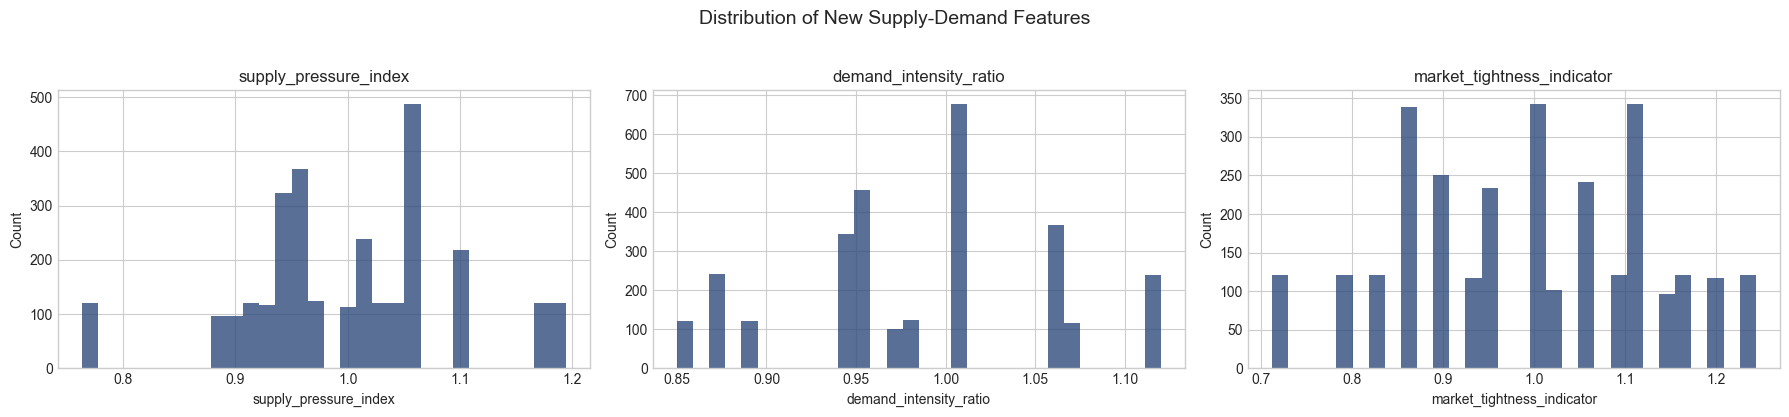

Saved figure: d:\data-analysis-for-tea-industry\reports\figures\t1_3_new_feature_distributions.png


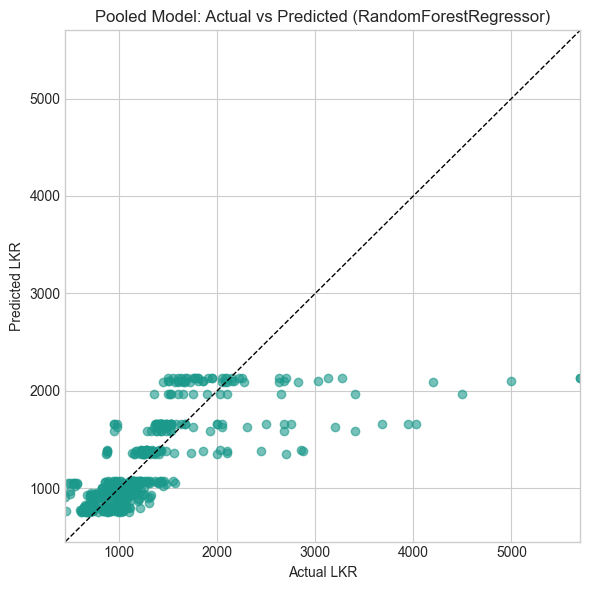

Saved figure: d:\data-analysis-for-tea-industry\reports\figures\t1_3_pooled_actual_vs_predicted.png


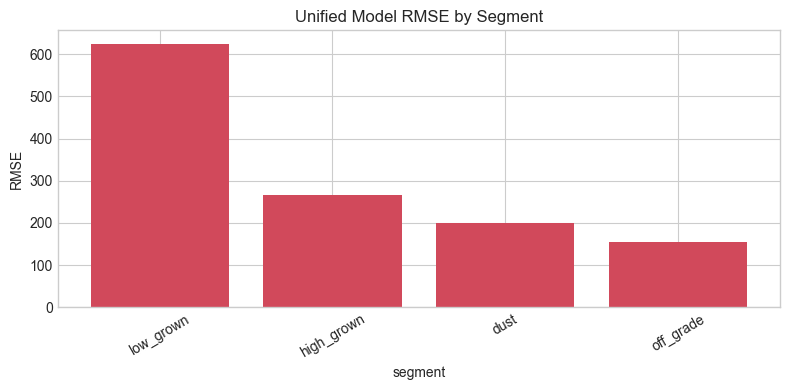

Saved figure: d:\data-analysis-for-tea-industry\reports\figures\t1_3_segment_rmse_unified.png


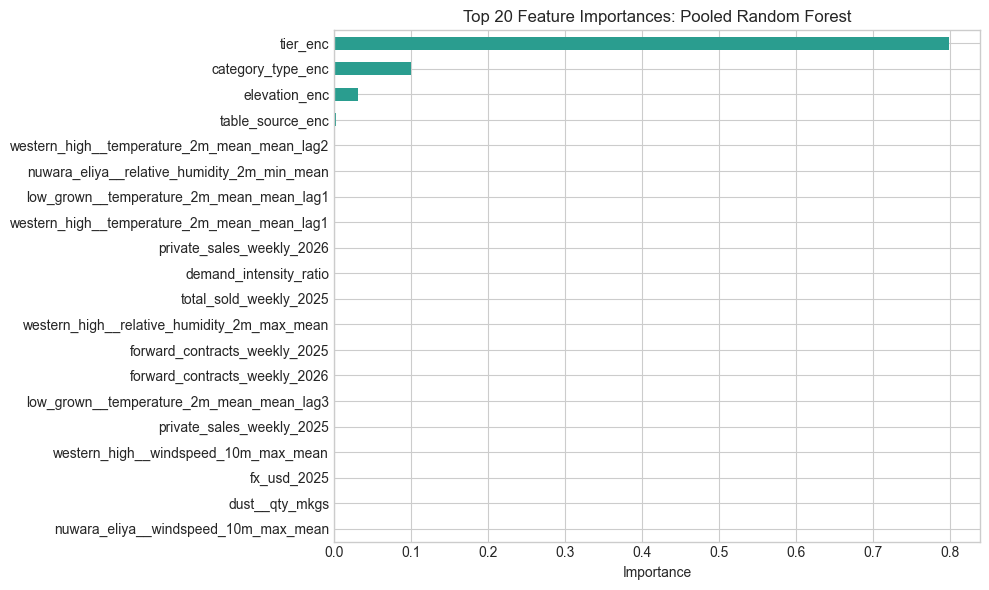

Saved figure: d:\data-analysis-for-tea-industry\reports\figures\t1_3_feature_importance.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, new_feature_cols):
    df_features[col].replace([np.inf, -np.inf], np.nan).dropna().plot(kind='hist', bins=30, ax=ax, color='#2F4B7C', alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
fig.suptitle('Distribution of New Supply-Demand Features', y=1.03, fontsize=14)
fig.tight_layout()
fig_path = reports_dir / 't1_3_new_feature_distributions.png'
fig.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved figure: {fig_path}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pooled_predictions['actual_lkr'], pooled_predictions['predicted_lkr'], alpha=0.6, color='#1B998B')
lims = [
    min(pooled_predictions['actual_lkr'].min(), pooled_predictions['predicted_lkr'].min()),
    max(pooled_predictions['actual_lkr'].max(), pooled_predictions['predicted_lkr'].max()),
]
ax.plot(lims, lims, '--', color='black', linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual LKR')
ax.set_ylabel('Predicted LKR')
ax.set_title(f'Pooled Model: Actual vs Predicted ({best_model_name})')
fig.tight_layout()
fig_path = reports_dir / 't1_3_pooled_actual_vs_predicted.png'
fig.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved figure: {fig_path}')

fig, ax = plt.subplots(figsize=(8, 4))
segment_plot = segment_metrics_unified.sort_values('rmse', ascending=False)
ax.bar(segment_plot['segment'].astype(str), segment_plot['rmse'], color='#D1495B')
ax.set_xlabel('segment')
ax.set_ylabel('RMSE')
ax.set_title('Unified Model RMSE by Segment')
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
fig_path = reports_dir / 't1_3_segment_rmse_unified.png'
fig.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved figure: {fig_path}')

if best_model_name == 'RandomForestRegressor' and hasattr(best_model.named_steps['regressor'], 'feature_importances_'):
    importances = pd.Series(best_model.named_steps['regressor'].feature_importances_, index=numeric_feature_cols).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    importances.head(20).sort_values().plot(kind='barh', ax=ax, color='#2A9D8F')
    ax.set_title('Top 20 Feature Importances: Pooled Random Forest')
    ax.set_xlabel('Importance')
    fig.tight_layout()
    fig_path = reports_dir / 't1_3_feature_importance.png'
    fig.savefig(fig_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved figure: {fig_path}')
else:
    print('Feature-importance plot skipped because the selected pooled model does not expose feature_importances_.')

## 10. Conclusions

Use the outputs above to write the paper-facing interpretation. A practical reading guide is:

- if the new supply-demand features rank highly in the random forest or improve RMSE relative to the baseline, they appear useful
- if the pooled model is close to or better than the segment-specific model on the held-out sales, the unified-market hypothesis gains support
- if segment-specific models still dominate, the paper should emphasize market heterogeneity rather than pooling

The text below can be updated after the notebook is executed with the actual comparison numbers.

In [ ]:
print('Pooled model summary')
print(pooled_results.to_string(index=False))

print('\nUnified segment metrics')
print(segment_metrics_unified.to_string(index=False))

if not normalized_segment_specific.empty and 'segment_specific_rmse' in comparison.columns and comparison['segment_specific_rmse'].notna().any():
    pooled_better = (comparison['segment_specific_rmse'] > comparison['unified_rmse']).sum()
    segment_better = (comparison['segment_specific_rmse'] < comparison['unified_rmse']).sum()
    equal = (comparison['segment_specific_rmse'] == comparison['unified_rmse']).sum()
    print('\nComparison summary')
    print(f'Unified better on {pooled_better} segment(s)')
    print(f'Segment-specific better on {segment_better} segment(s)')
    print(f'Equal on {equal} segment(s)')
else:
    print('\nSegment-specific results are not loaded yet. Add the benchmark file to complete the comparison.')

Pooled model summary
                model       rmse        mae       r2      mape
RandomForestRegressor 469.283103 253.855304 0.489927 18.231812
     LinearRegression 475.305132 255.737768 0.476752 18.350469

Unified segment metrics
   segment  n_rows       rmse        mae        r2      mape
 off_grade      97 155.934016 133.264720 -0.023383 16.476854
      dust     101 200.340625 160.228248  0.040705 17.257497
high_grown      48 265.860069 211.398364 -0.039993 23.865289
 low_grown     260 625.206401 343.053582  0.333028 18.225003

Segment-specific results are not loaded yet. Add the benchmark file to complete the comparison.


## Next Steps for Repo Integration

1. Move the market-structure feature construction into the preprocessing pipeline so `supply_pressure_index`, `demand_intensity_ratio`, and `market_tightness_indicator` are written into the processed dataset automatically.
2. Add a dedicated training script that reproduces the pooled baseline outside the notebook, saves metrics, and writes comparison tables for the paper workflow.
3. Persist the segment-specific benchmark table from the existing modeling notebook in a CSV file so the unified-vs-segment comparison can be regenerated programmatically.
4. Once the notebook stabilizes, extract the reusable helpers into `src/processing/` or `src/modeling/` modules so the paper figures and tables can be refreshed without editing notebook cells.